In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r".\Datasets\mobile-price-prediction.csv")
df

,Screen Size (inches),RAM (GB),Storage (GB),Battery Capacity (mAh),Camera Quality (MP),Price ($)
0,6.2,4,64,4000,48,500
1,6.1,3,128,3110,12,800
2,6.5,6,256,4500,64,600
3,6.7,8,128,4300,48,700
4,6.4,6,128,4200,40,550
...,...,...,...,...,...,...
287,6.0,6,64,3700,12,750
288,6.3,4,128,4025,32,450
289,6.6,8,256,5000,48,700
290,6.5,6,128,4500,64,550


In [3]:
df.columns = ['Screen_Size', 'RAM', 'Storage', 'Battery_Capacity', 'Camera_Quality', 'Price']
df

,Screen_Size,RAM,Storage,Battery_Capacity,Camera_Quality,Price
0,6.2,4,64,4000,48,500
1,6.1,3,128,3110,12,800
2,6.5,6,256,4500,64,600
3,6.7,8,128,4300,48,700
4,6.4,6,128,4200,40,550
...,...,...,...,...,...,...
287,6.0,6,64,3700,12,750
288,6.3,4,128,4025,32,450
289,6.6,8,256,5000,48,700
290,6.5,6,128,4500,64,550


In [4]:
df.dtypes

Screen_Size         float64
RAM                   int64
Storage               int64
Battery_Capacity      int64
Camera_Quality        int64
Price                 int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Screen_Size       292 non-null    float64
 1   RAM               292 non-null    int64  
 2   Storage           292 non-null    int64  
 3   Battery_Capacity  292 non-null    int64  
 4   Camera_Quality    292 non-null    int64  
 5   Price             292 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 13.8 KB


In [6]:
df.isnull().sum()

Screen_Size         0
RAM                 0
Storage             0
Battery_Capacity    0
Camera_Quality      0
Price               0
dtype: int64

In [7]:
for i in df.columns: print(i,':\n',df[i].unique())

Screen_Size :
 [6.2 6.1 6.5 6.7 6.4 6.  6.3 6.6 5.8 5.7 5.9 6.8 6.9]
RAM :
 [4 3 6 8]
Storage :
 [ 64 128 256  32]
Battery_Capacity :
 [4000 3110 4500 4300 4200 3700 4025 5000 3000 3500 3800 4100 4400 3100
 4600 4700]
Camera_Quality :
 [48 12 64 40 32 16 24 20]
Price :
 [500 800 600 700 550 750 450 400 650 900]


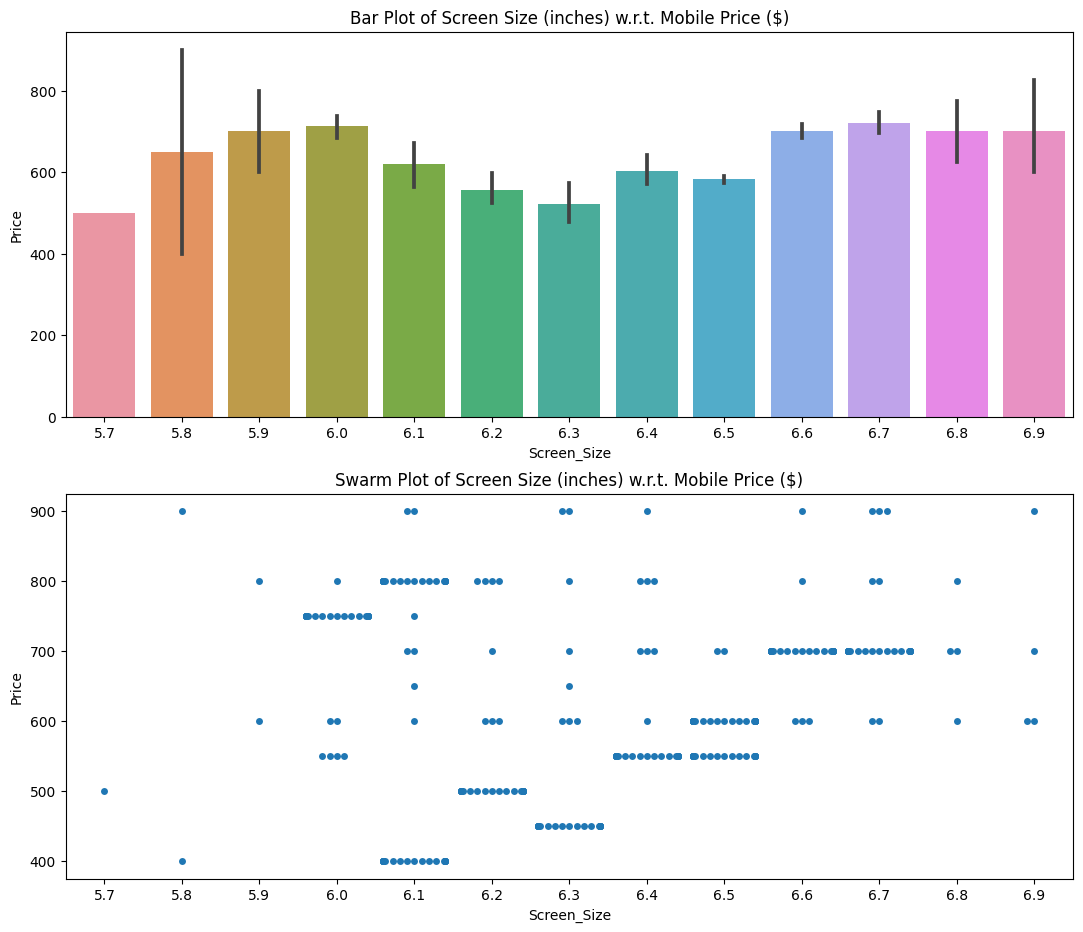

In [8]:
plt.figure(figsize = (13,11))
plt.subplot(211)
sns.barplot(data = df, x = 'Screen_Size', y = 'Price')
plt.title("Bar Plot of Screen Size (inches) w.r.t. Mobile Price ($)")
plt.subplot(212)
sns.swarmplot(x = df.Screen_Size, y = df.Price)
plt.title("Swarm Plot of Screen Size (inches) w.r.t. Mobile Price ($)")
plt.show()

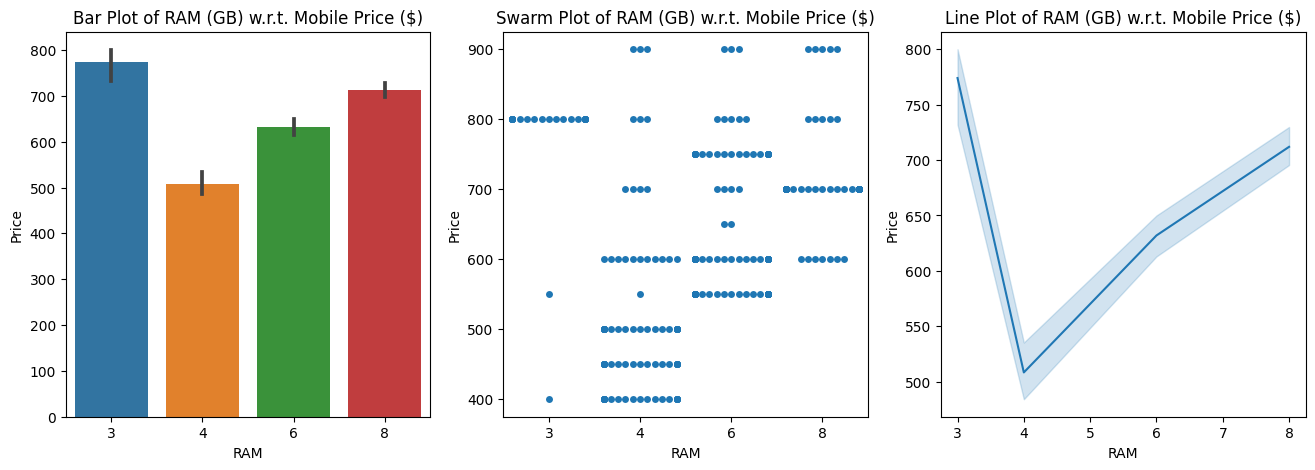

In [37]:
plt.figure(figsize = (16,5))
plt.subplot(131)
sns.barplot(data = df, x = 'RAM', y = 'Price')
plt.title("Bar Plot of RAM (GB) w.r.t. Mobile Price ($)")
plt.subplot(132)
sns.swarmplot(x = df.RAM, y = df.Price)
plt.title("Swarm Plot of RAM (GB) w.r.t. Mobile Price ($)")
plt.subplot(133)
sns.lineplot(data = df, x = 'RAM', y = 'Price')
plt.title("Line Plot of RAM (GB) w.r.t. Mobile Price ($)")
plt.show()

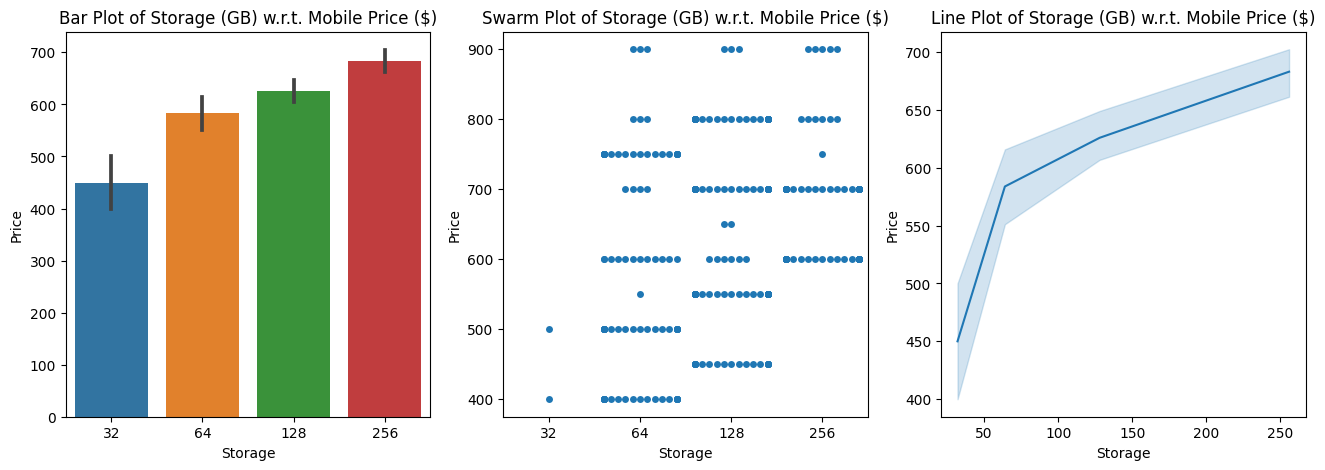

In [10]:
plt.figure(figsize = (16,5))
plt.subplot(131)
sns.barplot(data = df, x = 'Storage', y = 'Price')
plt.title("Bar Plot of Storage (GB) w.r.t. Mobile Price ($)")
plt.subplot(132)
sns.swarmplot(x = df.Storage, y = df.Price)
plt.title("Swarm Plot of Storage (GB) w.r.t. Mobile Price ($)")
plt.subplot(133)
sns.lineplot(data = df, x = 'Storage', y = 'Price')
plt.title("Line Plot of Storage (GB) w.r.t. Mobile Price ($)")
plt.show()

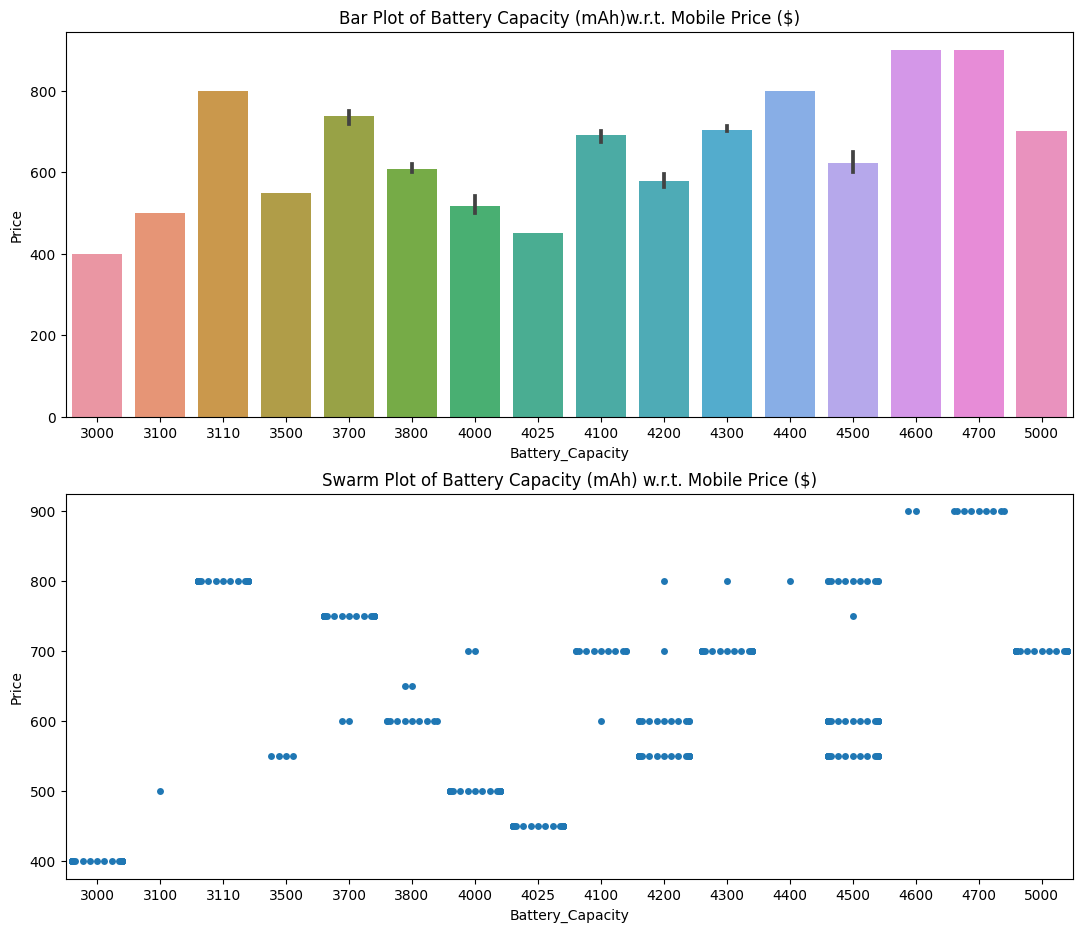

In [11]:
plt.figure(figsize = (13,11))
plt.subplot(211)
sns.barplot(data = df, x = 'Battery_Capacity', y = 'Price')
plt.title("Bar Plot of Battery Capacity (mAh)w.r.t. Mobile Price ($)")
plt.subplot(212)
sns.swarmplot(x = df.Battery_Capacity, y = df.Price)
plt.title("Swarm Plot of Battery Capacity (mAh) w.r.t. Mobile Price ($)")
plt.show()

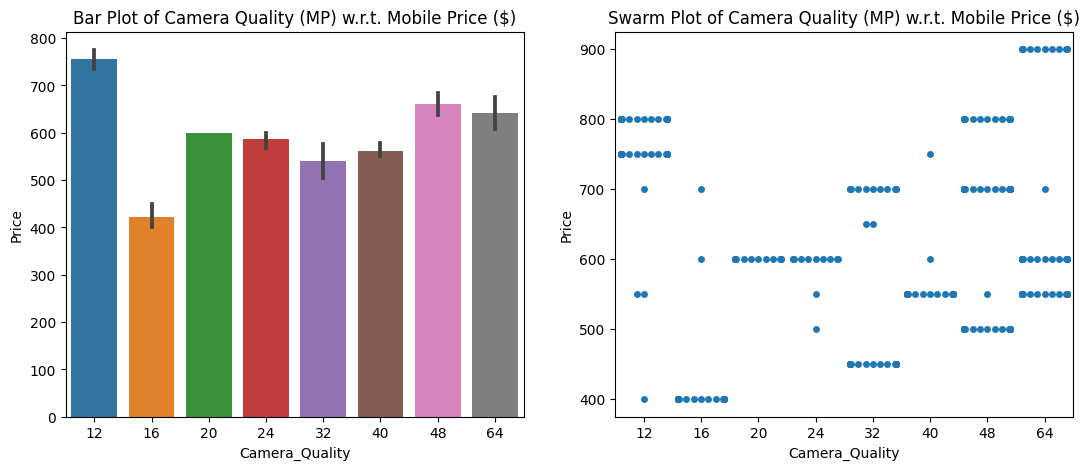

In [12]:
plt.figure(figsize = (13,5))
plt.subplot(121)
sns.barplot(data = df, x = 'Camera_Quality', y = 'Price')
plt.title("Bar Plot of Camera Quality (MP) w.r.t. Mobile Price ($)")
plt.subplot(122)
sns.swarmplot(x = df.Camera_Quality, y = df.Price)
plt.title("Swarm Plot of Camera Quality (MP) w.r.t. Mobile Price ($)")
plt.show()

sns.pairplot(df, hue = 'Price')
plt.show()

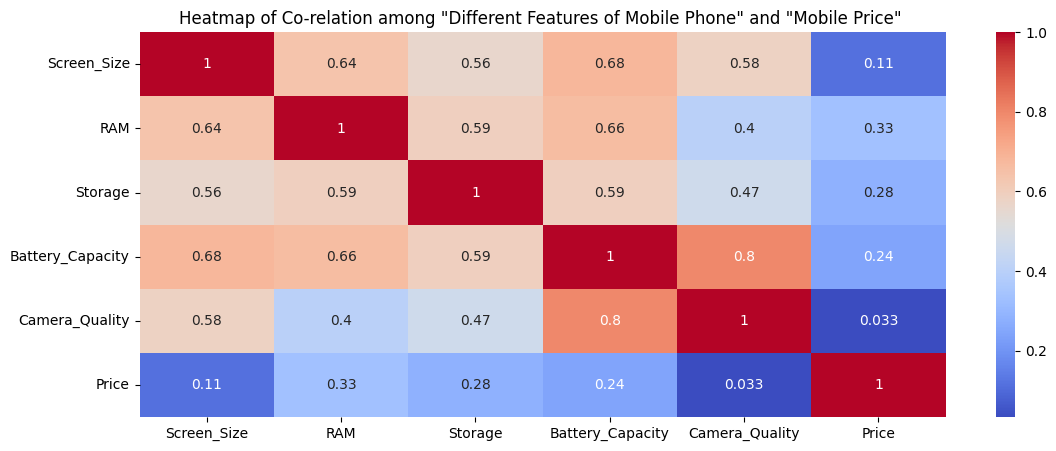

In [13]:
plt.figure(figsize = (13,5))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.title('Heatmap of Co-relation among "Different Features of Mobile Phone" and "Mobile Price" ')
plt.show()

In [14]:
ip = df.drop(['Price'], axis = 1)
ip

,Screen_Size,RAM,Storage,Battery_Capacity,Camera_Quality
0,6.2,4,64,4000,48
1,6.1,3,128,3110,12
2,6.5,6,256,4500,64
3,6.7,8,128,4300,48
4,6.4,6,128,4200,40
...,...,...,...,...,...
287,6.0,6,64,3700,12
288,6.3,4,128,4025,32
289,6.6,8,256,5000,48
290,6.5,6,128,4500,64


In [15]:
op = df['Price']
op

0      500
1      800
2      600
3      700
4      550
      ... 
287    750
288    450
289    700
290    550
291    400
Name: Price, Length: 292, dtype: int64

In [16]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.8)

In [17]:
df.shape, x_train.shape, x_test.shape

((292, 6), (233, 5), (59, 5))

In [18]:
sc = StandardScaler()
sc

StandardScaler()

In [19]:
x_train = sc.fit_transform(x_train)
x_train

array([[ 0.63957389,  0.23646245, -0.12742975,  0.77748644,  1.48872074],
       [-1.43015827,  0.23646245, -1.02716102, -0.70321315, -1.45663205],
       [ 0.63957389,  0.23646245,  1.67203278,  0.77748644,  1.48872074],
       ...,
       [ 0.63957389,  0.23646245,  1.67203278,  0.77748644,  1.48872074],
       [-0.18831898, -0.96127126, -0.12742975, -0.10167894, -0.32380405],
       [-1.01621184, -0.96127126, -1.02716102, -1.99882529, -1.23006645]])

In [20]:
x_test = sc.fit_transform(x_test)
x_test

array([[-1.35984242,  0.28639257, -1.0765209 , -0.50738959, -1.27206518],
       [-1.35984242,  0.28639257, -1.0765209 , -0.50738959, -1.27206518],
       [ 0.19050932,  0.28639257, -0.14248071,  0.34573055,  0.08897865],
       [ 2.12844901,  1.53803415,  1.72559967, -0.33676556, -0.68876068],
       [ 0.57809726,  0.28639257,  1.72559967,  0.85760263,  1.25558765],
       [-0.97225449, -1.59106981, -0.14248071, -1.51407135, -1.27206518],
       [ 1.74086107,  1.53803415,  1.72559967,  0.17510652, -0.29989101],
       [ 0.19050932,  0.28639257, -0.14248071,  1.19885069,  1.25558765],
       [ 0.57809726,  0.28639257,  1.72559967,  0.85760263,  1.25558765],
       [ 0.9656852 ,  0.28639257, -0.14248071, -0.33676556, -0.68876068],
       [ 1.35327314,  1.53803415, -0.14248071,  0.51635458,  0.47784832],
       [-0.97225449, -1.59106981, -0.14248071, -1.51407135, -1.27206518],
       [-0.97225449, -0.96524902, -1.0765209 , -1.70175778, -1.07763035],
       [ 0.57809726,  0.28639257, -0.1

In [21]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [22]:
ycap = lr.predict(x_test)
ycap

array([670.49305167, 670.49305167, 636.286858  , 673.48833099,
       653.82400033, 564.908222  , 693.76147407, 631.80641889,
       653.82400033, 610.71796811, 643.7946061 , 564.908222  ,
       549.96438211, 605.04733068, 549.96438211, 564.908222  ,
       643.7946061 , 756.77385464, 605.04733068, 564.908222  ,
       605.04733068, 564.908222  , 599.59920243, 791.30525035,
       643.7946061 , 557.17109848, 557.17109848, 549.96438211,
       549.96438211, 605.04733068, 605.04733068, 605.04733068,
       653.82400033, 549.96438211, 564.908222  , 548.67964733,
       670.49305167, 670.49305167, 644.77830915, 670.49305167,
       605.04733068, 653.82400033, 605.04733068, 599.59920243,
       599.59920243, 756.77385464, 653.82400033, 643.7946061 ,
       670.49305167, 585.21492146, 622.49966005, 596.46134308,
       653.82400033, 564.908222  , 569.86100697, 756.77385464,
       681.97978213, 636.286858  , 557.17109848])

In [23]:
pdf = pd.DataFrame({'y':list(y_test),
                    'Prediction':ycap})
pdf

,y,Prediction
0,750,670.493052
1,750,670.493052
2,550,636.286858
3,600,673.488331
4,600,653.824000
5,800,564.908222
6,700,693.761474
7,900,631.806419
8,600,653.824000
9,600,610.717968


In [24]:
mse = mean_squared_error(y_test, ycap)
print("Mean Squared Error: ", mse)

Mean Squared Error:  17576.67175366696


In [25]:
r2 = r2_score(y_test, ycap)
print("R2 Score:", r2)
print("Accuracy:", r2*100)

R2 Score: 0.03281071175285044
Accuracy: 3.281071175285044


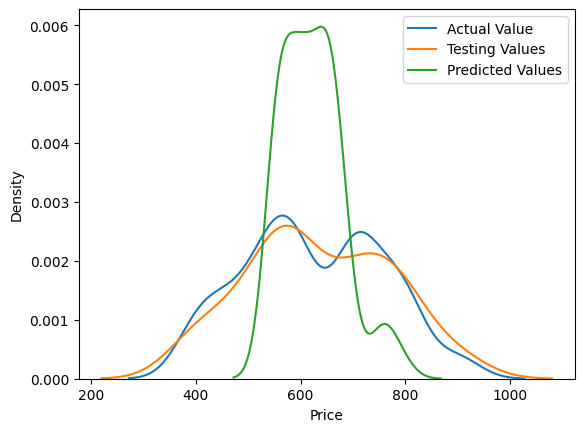

In [26]:
sns.kdeplot(df["Price"], label = "Actual Value")
sns.kdeplot(y_test, label = "Testing Values")
sns.kdeplot(ycap, label = "Predicted Values")
plt.legend()
plt.show()

----

In [27]:
poly = PolynomialFeatures(degree = 2)
poly

PolynomialFeatures()

In [28]:
x_poly = poly.fit_transform(x_train)
x_poly

array([[ 1.        ,  0.63957389,  0.23646245, ...,  0.60448516,
         1.15746019,  2.21628943],
       [ 1.        , -1.43015827,  0.23646245, ...,  0.49450873,
         1.02432281,  2.12177692],
       [ 1.        ,  0.63957389,  0.23646245, ...,  0.60448516,
         1.15746019,  2.21628943],
       ...,
       [ 1.        ,  0.63957389,  0.23646245, ...,  0.60448516,
         1.15746019,  2.21628943],
       [ 1.        , -0.18831898, -0.96127126, ...,  0.01033861,
         0.03292405,  0.10484906],
       [ 1.        , -1.01621184, -0.96127126, ...,  3.99530255,
         2.45868793,  1.51306347]])

In [29]:
lp = LinearRegression()
lp

LinearRegression()

In [30]:
lp.fit(x_poly, y_train)
x1 = poly.fit_transform(x_test)
x1

array([[ 1.00000000e+00, -1.35984242e+00,  2.86392566e-01, ...,
         2.57444192e-01,  6.45432627e-01,  1.61814983e+00],
       [ 1.00000000e+00, -1.35984242e+00,  2.86392566e-01, ...,
         2.57444192e-01,  6.45432627e-01,  1.61814983e+00],
       [ 1.00000000e+00,  1.90509325e-01,  2.86392566e-01, ...,
         1.19529613e-01,  3.07626386e-02,  7.91720063e-03],
       ...,
       [ 1.00000000e+00,  2.12844901e+00,  1.53803415e+00, ...,
         3.06622944e-02, -5.25128729e-02,  8.99346206e-02],
       [ 1.00000000e+00,  1.90509325e-01,  2.86392566e-01, ...,
         1.19529613e-01,  3.07626386e-02,  7.91720063e-03],
       [ 1.00000000e+00, -5.84666549e-01, -9.65249020e-01, ...,
         2.00927671e-05,  2.14195301e-03,  2.28339017e-01]])

In [31]:
ycap2 = lp.predict(x1)
ycap2

array([795.32362492, 795.32362492, 624.09137361, 808.84370515,
       600.49644191, 711.70179548, 730.8127018 , 793.83371024,
       600.49644191, 529.10610133, 781.66651029, 711.70179548,
       414.8536924 , 667.64837406, 414.8536924 , 711.70179548,
       781.66651029, 710.50809532, 667.64837406, 711.70179548,
       667.64837406, 711.70179548, 469.72593988, 906.07014691,
       781.66651029, 563.65493001, 563.65493001, 414.8536924 ,
       414.8536924 , 667.64837406, 667.64837406, 667.64837406,
       600.49644191, 414.8536924 , 711.70179548, 475.65328424,
       795.32362492, 795.32362492, 743.98628894, 795.32362492,
       667.64837406, 600.49644191, 667.64837406, 469.72593988,
       469.72593988, 710.50809532, 600.49644191, 781.66651029,
       795.32362492, 542.68680439, 516.00616097, 829.0772415 ,
       600.49644191, 711.70179548, 869.5007115 , 710.50809532,
       774.81626631, 624.09137361, 563.65493001])

In [32]:
pdf1 = pd.DataFrame({'y':list(y_test),
                    'Prediction':ycap2})
pdf1

,y,Prediction
0,750,795.323625
1,750,795.323625
2,550,624.091374
3,600,808.843705
4,600,600.496442
5,800,711.701795
6,700,730.812702
7,900,793.833710
8,600,600.496442
9,600,529.106101


In [33]:
mse = mean_squared_error(y_test, ycap2)
print("Mean Squared Error: ", mse)

Mean Squared Error:  7150.058080074043


In [34]:
r2p = r2_score(y_test, ycap2)
print("R2 Score:", r2p)
print("Accuracy:", r2p*100)

R2 Score: 0.6065546605005099
Accuracy: 60.65546605005099


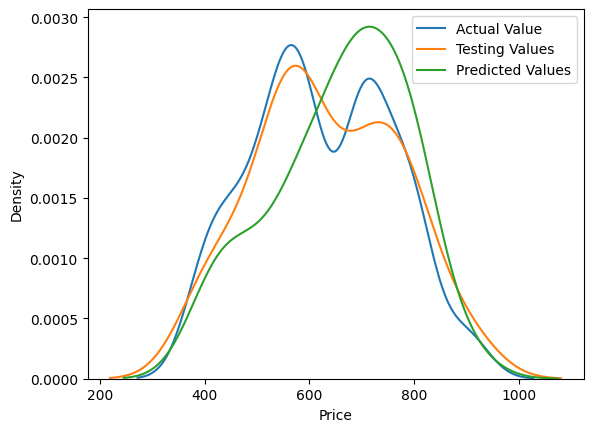

In [35]:
sns.kdeplot(df["Price"], label = "Actual Value")
sns.kdeplot(y_test, label = "Testing Values")
sns.kdeplot(ycap2, label = "Predicted Values")
plt.legend()
plt.show()